# Анализ экспериментов музейного комплекса

Загрузка и визуализация результатов: основной датасет `results.csv`, при наличии — дополнительно `ai_results.csv` (эксперименты с ИИ-управлением). Объединённый датафрейм помечается столбцом `isAiPowered`.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (10, 5)

results_path = Path('results.csv')
ai_path = Path('ai_results.csv')

df_base = pd.read_csv(results_path)
if 'investMinProb' not in df_base.columns:
    df_base['investMinProb'] = 0.1
df_base['isAiPowered'] = 0

if ai_path.exists():
    df_ai = pd.read_csv(ai_path)
    if 'investMinProb' not in df_ai.columns:
        if 'numVisitors' in df_ai.columns:
            df_ai.insert(df_ai.columns.get_loc('numVisitors'), 'investMinProb', 0.0)
        else:
            df_ai['investMinProb'] = 0.0
    df_ai['isAiPowered'] = 1
    df = pd.concat([df_base, df_ai], ignore_index=True)
    print(f'Загружено {len(df_base)} строк из results.csv и {len(df_ai)} из ai_results.csv, всего {len(df)}.')
else:
    df = df_base
    print(f'Файл ai_results.csv не найден — только results.csv ({len(df)} строк).')

infra_cols = [
    'finalMobileNetwork', 'finalPaymentSystem', 'finalTransportAccess',
    'finalInternetQuality', 'finalNavigationAccess', 'finalServiceAvailability',
]
df['finalInfrastructure'] = df[infra_cols].mean(axis=1)

print('isAiPowered:', df['isAiPowered'].value_counts().to_dict())
df.head()

Загружено 288 строк из results.csv и 8 из ai_results.csv, всего 296.
isAiPowered: {0: 288, 1: 8}


,museumCapacity,hotelCapacity,ticketPrice,hotelPrice,monthlyExpenditures,investMinProb,numVisitors,maxDays,totalVisits,totalHotelStays,...,finalBudget,finalMobileNetwork,finalPaymentSystem,finalTransportAccess,finalInternetQuality,finalNavigationAccess,finalServiceAvailability,finalAvgReview,isAiPowered,finalInfrastructure
0,10,5,20,30,5000,0.1,65,365,894,272,...,-28960.0,36.60,36.60,39.05,39.05,39.05,39.05,14.48,0,38.233333
1,10,5,20,30,5000,0.1,65,365,1019,297,...,-25710.0,34.73,34.73,39.05,39.05,39.05,39.05,25.46,0,37.610000
2,10,5,20,30,5000,0.1,65,730,1120,314,...,-83180.0,33.20,33.20,28.10,28.10,28.10,28.10,0.00,0,29.800000
3,10,5,20,30,5000,0.1,65,730,1234,383,...,-78830.0,31.49,31.49,28.10,28.10,28.10,28.10,0.00,0,29.230000
4,10,5,20,30,5000,0.8,65,365,1008,277,...,-26530.0,34.88,34.88,39.05,39.05,39.05,39.05,22.75,0,37.660000


In [ ]:
df.describe().round(2)

## 1. Доля экспериментов с положительным бюджетом

In [ ]:
positive = (df['finalBudget'] > 0).sum()
total = len(df)
print(f'Положительный бюджет: {positive}/{total} ({positive/total*100:.1f}%)')
print(f'Отрицательный бюджет: {total - positive}/{total} ({(total-positive)/total*100:.1f}%)')
print(f'Средний итоговый бюджет: {df["finalBudget"].mean():.0f}')
print(f'Медиана итогового бюджета: {df["finalBudget"].median():.0f}')

fig, ax = plt.subplots()
ax.hist(df['finalBudget'], bins=30, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', label='Безубыточность')
ax.set_xlabel('Итоговый бюджет')
ax.set_ylabel('Число экспериментов')
ax.set_title('Распределение итогового бюджета')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Влияние цены билета на бюджет и посещаемость

In [ ]:
grouped = df.groupby('ticketPrice').agg(
    avgBudget=('finalBudget', 'mean'),
    avgVisits=('totalVisits', 'mean'),
    avgReview=('finalAvgReview', 'mean'),
    positivePct=('finalBudget', lambda x: (x > 0).mean() * 100)
).round(1)
print(grouped)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(grouped.index.astype(str), grouped['avgBudget'], color=['#d9534f' if v < 0 else '#5cb85c' for v in grouped['avgBudget']], edgecolor='black')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('Цена билета')
axes[0].set_ylabel('Средний итоговый бюджет')
axes[0].set_title('Бюджет vs Цена билета')

axes[1].bar(grouped.index.astype(str), grouped['avgVisits'], color='steelblue', edgecolor='black')
axes[1].set_xlabel('Цена билета')
axes[1].set_ylabel('Среднее число визитов')
axes[1].set_title('Посещаемость vs Цена билета')

plt.tight_layout()
plt.show()

## 3. Влияние вместимости музея на доход и отказы

In [ ]:
grouped_cap = df.groupby('museumCapacity').agg(
    avgBudget=('finalBudget', 'mean'),
    avgVisits=('totalVisits', 'mean'),
    avgRefusals=('totalRefusals', 'mean'),
    avgWear=('finalWear', 'mean')
).round(1)
print(grouped_cap)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(grouped_cap.index, grouped_cap['avgVisits'], 'o-', label='Визиты', color='steelblue')
axes[0].set_xlabel('Вместимость музея')
axes[0].set_ylabel('Среднее число визитов')
axes[0].set_title('Посещаемость vs Вместимость')
axes[0].legend()

axes[1].plot(grouped_cap.index, grouped_cap['avgRefusals'], 's-', label='Отказы', color='#d9534f')
axes[1].set_xlabel('Вместимость музея')
axes[1].set_ylabel('Среднее число отказов')
axes[1].set_title('Отказы vs Вместимость')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Матрица корреляций ключевых метрик

In [ ]:
cols = ['ticketPrice', 'museumCapacity', 'hotelCapacity', 'hotelPrice',
        'totalVisits', 'totalHotelStays', 'totalRefusals',
        'finalBudget', 'finalWear', 'finalAttractiveness', 'finalAvgReview']
corr = df[cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(cols, fontsize=8)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Корреляция входных параметров и итоговых метрик')
plt.tight_layout()
plt.show()

## 5. Scatter: Визиты vs Итоговый бюджет (по цене билета)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
for price, grp in df.groupby('ticketPrice'):
    ax.scatter(grp['totalVisits'], grp['finalBudget'], label=f'ticket={price}', alpha=0.6, s=30)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('Общее число визитов')
ax.set_ylabel('Итоговый бюджет')
ax.set_title('Визиты vs Бюджет (цвет = цена билета)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Boxplot: итоговый бюджет по комбинации (ticketPrice x hotelPrice)

In [ ]:
df['price_combo'] = df['ticketPrice'].astype(str) + '/' + df['hotelPrice'].astype(str)
combos_sorted = sorted(df['price_combo'].unique(), key=lambda x: (int(x.split('/')[0]), int(x.split('/')[1])))

fig, ax = plt.subplots(figsize=(12, 5))
data_groups = [df[df['price_combo'] == c]['finalBudget'].values for c in combos_sorted]
bp = ax.boxplot(data_groups, labels=combos_sorted, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('ticketPrice / hotelPrice')
ax.set_ylabel('Итоговый бюджет')
ax.set_title('Распределение бюджета по ценовым комбинациям')
plt.tight_layout()
plt.show()

df.drop(columns=['price_combo'], inplace=True)

## 7. Влияние investMinProb на итоговый бюджет

Параметр `investMinProb` задаёт нижнюю границу вероятности инвестирования менеджером при дефиците «ремонтного фонда» (см. `manager.asl`, приоритет 4). В `results.csv` он записывается около `monthlyExpenditures`.

In [ ]:
if 'investMinProb' not in df.columns:
    print('Колонка investMinProb отсутствует: перезапустите эксперименты с обновлённым experiment.json и MuseumEnv.')
elif 'isAiPowered' in df.columns:
    df_imp = df[df['isAiPowered'] == 0]
    if df_imp.empty:
        print('Нет строк без ИИ (isAiPowered=0) для анализа investMinProb.')
    else:
        grp_imp = df_imp.groupby('investMinProb').agg(
            avgBudget=('finalBudget', 'mean'),
            medianBudget=('finalBudget', 'median'),
            avgVisits=('totalVisits', 'mean'),
        ).round(1)
        print(grp_imp)

        levels = sorted(df_imp['investMinProb'].unique())
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        data_groups = [df_imp[df_imp['investMinProb'] == v]['finalBudget'].values for v in levels]
        bp = axes[0].boxplot(data_groups, tick_labels=[str(v) for v in levels], patch_artist=True)
        for patch in bp['boxes']:
            patch.set_facecolor('lightgreen')
        axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
        axes[0].set_xlabel('investMinProb')
        axes[0].set_ylabel('Итоговый бюджет')
        axes[0].set_title('Распределение finalBudget по investMinProb')

        axes[1].bar(range(len(levels)), grp_imp['avgBudget'].values, color='steelblue', edgecolor='black')
        axes[1].set_xticks(range(len(levels)))
        axes[1].set_xticklabels([str(v) for v in levels])
        axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)
        axes[1].set_xlabel('investMinProb')
        axes[1].set_ylabel('Средний итоговый бюджет')
        axes[1].set_title('Средний finalBudget по investMinProb')

        plt.tight_layout()
        plt.show()
else:
    grp_imp = df.groupby('investMinProb').agg(
        avgBudget=('finalBudget', 'mean'),
        medianBudget=('finalBudget', 'median'),
        avgVisits=('totalVisits', 'mean'),
    ).round(1)
    print(grp_imp)

    levels = sorted(df['investMinProb'].unique())
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    data_groups = [df[df['investMinProb'] == v]['finalBudget'].values for v in levels]
    bp = axes[0].boxplot(data_groups, tick_labels=[str(v) for v in levels], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightgreen')
    axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
    axes[0].set_xlabel('investMinProb')
    axes[0].set_ylabel('Итоговый бюджет')
    axes[0].set_title('Распределение finalBudget по investMinProb')

    axes[1].bar(range(len(levels)), grp_imp['avgBudget'].values, color='steelblue', edgecolor='black')
    axes[1].set_xticks(range(len(levels)))
    axes[1].set_xticklabels([str(v) for v in levels])
    axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)
    axes[1].set_xlabel('investMinProb')
    axes[1].set_ylabel('Средний итоговый бюджет')
    axes[1].set_title('Средний finalBudget по investMinProb')

    plt.tight_layout()
    plt.show()

## 8. Сравнение: ИИ vs классический менеджер (`isAiPowered`)

Столбец `isAiPowered`: 0 — результаты из `results.csv`, 1 — из `ai_results.csv`. Для ИИ-запусков `investMinProb` заполнен нулём и в сравнении по этому параметру не используется. `finalInfrastructure` — среднее по шести показателям инфраструктуры из CSV.

In [ ]:
if 'isAiPowered' not in df.columns or df['isAiPowered'].nunique() < 2:
    print('Нужны оба набора: убедитесь, что загружены results.csv и ai_results.csv, и перезапустите первую ячейку.')
else:
    compare_cols = ['finalWear', 'finalBudget', 'finalAttractiveness', 'finalInfrastructure']
    ai_summary = df.groupby('isAiPowered')[compare_cols].agg(['mean', 'median', 'std']).round(2)
    print('Сводка по группам (0 = без ИИ, 1 = с ИИ):')
    print(ai_summary)

    labels = ['без ИИ', 'с ИИ']
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    axes = axes.ravel()
    for ax, col in zip(axes, compare_cols):
        data_groups = [df[df['isAiPowered'] == v][col].values for v in (0, 1)]
        bp = ax.boxplot(data_groups, tick_labels=labels, patch_artist=True)
        for patch, color in zip(bp['boxes'], ['lightsteelblue', 'wheat']):
            patch.set_facecolor(color)
        ax.set_ylabel(col)
        ax.set_title(f'Распределение {col}')
    plt.suptitle('Сравнение метрик: ИИ vs не-ИИ', y=1.02)
    plt.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(10, 5))
    means = df.groupby('isAiPowered')[compare_cols].mean()
    x = range(len(compare_cols))
    w = 0.35
    ax2.bar([i - w / 2 for i in x], means.loc[0], width=w, label='без ИИ', color='steelblue', edgecolor='black')
    ax2.bar([i + w / 2 for i in x], means.loc[1], width=w, label='с ИИ', color='darkorange', edgecolor='black')
    ax2.set_xticks(list(x))
    ax2.set_xticklabels(compare_cols, rotation=15, ha='right')
    ax2.set_ylabel('Среднее значение')
    ax2.set_title('Средние finalWear, finalBudget, finalAttractiveness, finalInfrastructure')
    ax2.legend()
    ax2.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    plt.tight_layout()
    plt.show()

## 9. Сравнение MAS и системной динамики (AnyLogic, `sd_results.csv`)

### Стратегия сопоставления

**Общие «физические» смыслы столбцов**

| SD (`sd_results.csv`) | MAS (`results.csv`) / производное |
|----------------------|-----------------------------------|
| `monthlyCosts` | `monthlyExpenditures` |
| `combinedPrice` | `ticketPrice + 0.3 × hotelPrice` (как в отчёте ЛР3: доля отеля в доходе) |
| `N` | `numVisitors` |
| `defaultCapacity` | `museumCapacity` |
| `budget`, `wear`, `infra`, `attract` | `finalBudget`, `finalWear`, `finalInfrastructure` (среднее 6 полей), `finalAttractiveness` |

**Почему наборы не совпадают один в один**

- В MAS одновременно варьируются `investMinProb`, `maxDays`, `hotelCapacity` и др.; в SD — один скаляр `combinedPrice` и иная сетка значений.
- Сетка цен: MAS даёт дискретные `combinedPrice_mas` из пары (билет, отель), тогда как в экспериментах SD часто задаются другие уровни (например 30, 50, 70…). **Точного совпадения по цене может не быть** — используется сопоставление **ближайшего соседа** по `combinedPrice` при совпадении остальных ключей (расходы, N, вместимость).
- Горизонт: для сопоставления с SD по умолчанию берём MAS-строки с **`maxDays == 365`** (можно ослабить в коде).

**Нормализация и проверка трендов**

- **Z-нормировка** внутри каждой выборки (MAS-агрегат vs SD) по совмещённым точкам — чтобы сравнивать направления при разном масштабе абсолютных значений.
- **Корреляции Спирмена** метрик с `combinedPrice` отдельно по полному SD и по отфильтрованному MAS: совпадение **знака** и близость коэффициентов интерпретируются как сохранение тренда.
- Диаграммы рассеяния «MAS vs SD» по сопоставленным точкам (сырые и z-оценки).

Дополнительно в AnyLogic имеет смысл в будущем выгружать **те же** варианты, что и в `experiment.json` MAS (или явно задавать `combinedPrice` как в отчёте), чтобы включить **точное** объединение по ключу без ближайшего соседа.

Сопоставлено пар SD↔MAS (ближайший combinedPrice): 15 из 90 строк SD.
Средний |Δ combinedPrice| (MAS vs SD): 16.200

Корреляция Спирмена с combinedPrice (SD: combinedPrice_sd; MAS: ticketPrice+0.3*hotelPrice):
model      MAS     SD
metric               
attract  0.716  0.581
budget   0.964  0.960
infra    0.684  0.665
wear    -0.712 -0.546


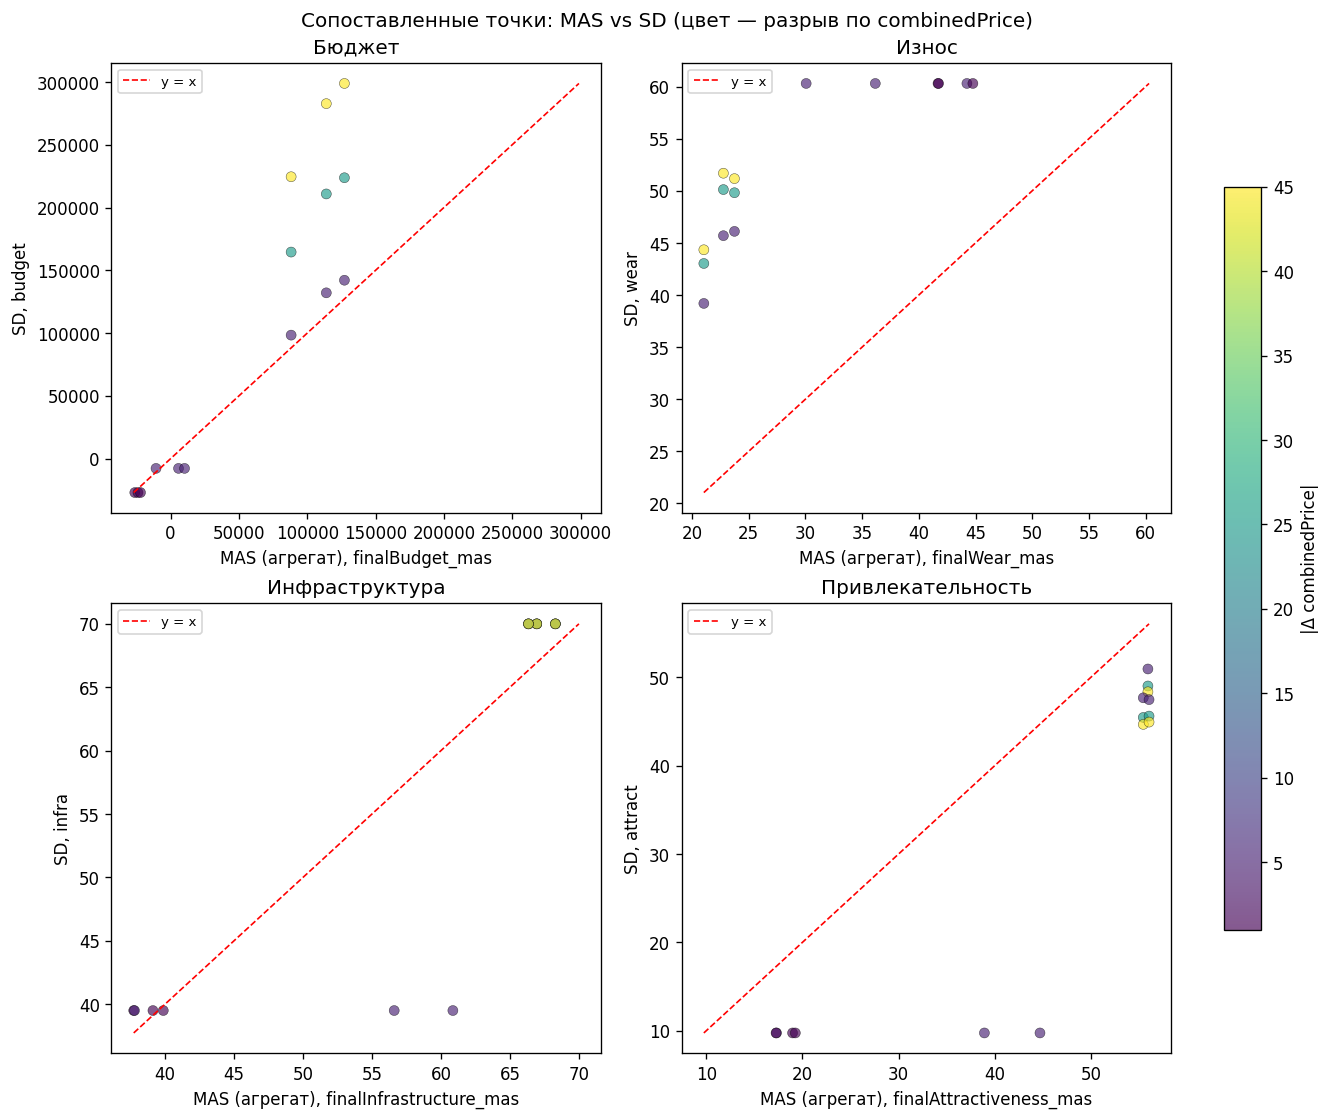

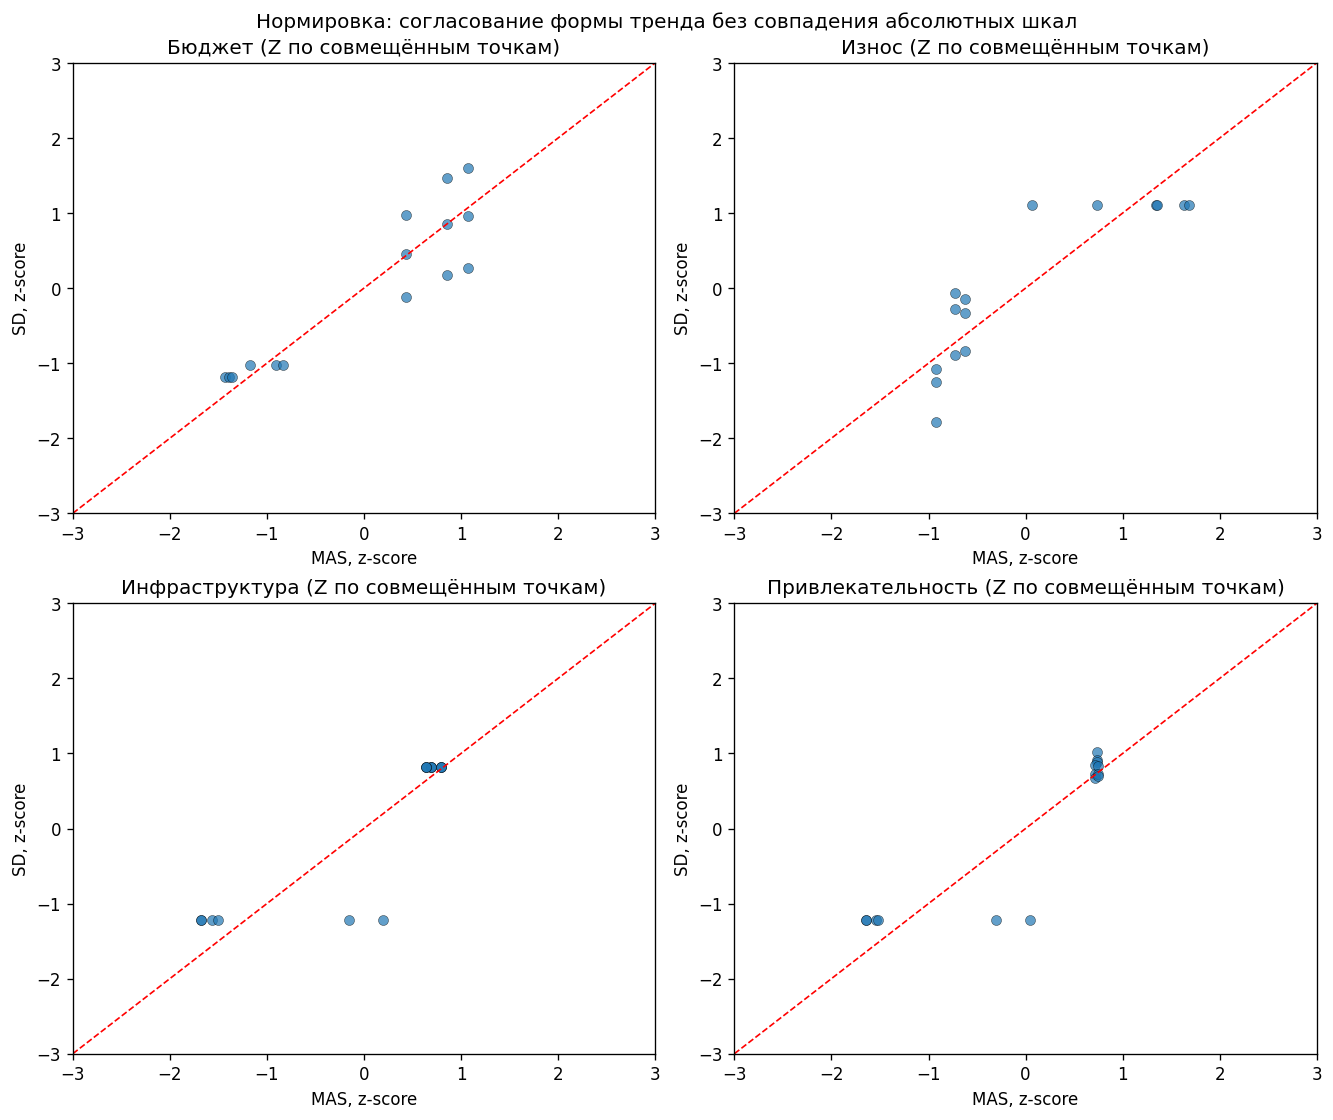


Тренды на сопоставленных точках (Спирмен vs combinedPrice SD):
              metric  rho_MAS_vs_price  rho_SD_vs_price  same_sign
0             Бюджет            0.7941           0.9891       True
1              Износ           -0.7721          -0.6480       True
2     Инфраструктура            0.7721           0.7832       True
3  Привлекательность            0.7721           0.6480       True


In [17]:
import numpy as np

sd_path = Path('sd_results.csv')
if not sd_path.exists():
    print('Файл sd_results.csv не найден в папке experiments.')
else:
    df_sd_raw = pd.read_csv(sd_path)
    sd = df_sd_raw.rename(columns={
        'monthlyCosts': 'monthlyExpenditures',
        'combinedPrice': 'combinedPrice_sd',
        'N': 'numVisitors',
        'defaultCapacity': 'museumCapacity',
    })

    mas_f = df[df['isAiPowered'] == 0].copy()
    USE_MAS_365_ONLY = True
    if USE_MAS_365_ONLY and 'maxDays' in mas_f.columns:
        mas_w = mas_f[mas_f['maxDays'] == 365].copy()
        if mas_w.empty:
            print('После фильтра maxDays==365 нет строк MAS — используем все maxDays.')
            mas_w = mas_f
    else:
        mas_w = mas_f

    mas_w['combinedPrice_mas'] = mas_w['ticketPrice'] + 0.3 * mas_w['hotelPrice']

    key_shared = ['monthlyExpenditures', 'numVisitors', 'museumCapacity']
    mas_agg = mas_w.groupby(key_shared + ['combinedPrice_mas'], as_index=False).agg(
        finalBudget=('finalBudget', 'mean'),
        finalWear=('finalWear', 'mean'),
        finalAttractiveness=('finalAttractiveness', 'mean'),
        finalInfrastructure=('finalInfrastructure', 'mean'),
    )

    rows = []
    for _, s in sd.iterrows():
        sub = mas_agg[
            (mas_agg['monthlyExpenditures'] == s['monthlyExpenditures'])
            & (mas_agg['numVisitors'] == s['numVisitors'])
            & (mas_agg['museumCapacity'] == s['museumCapacity'])
        ]
        if sub.empty:
            continue
        dist = (sub['combinedPrice_mas'] - s['combinedPrice_sd']).abs()
        j = dist.idxmin()
        r = sub.loc[j]
        rows.append({
            **s.to_dict(),
            'combinedPrice_mas': r['combinedPrice_mas'],
            'cp_abs_gap': float(dist.loc[j]),
            'finalBudget_mas': r['finalBudget'],
            'finalWear_mas': r['finalWear'],
            'finalAttractiveness_mas': r['finalAttractiveness'],
            'finalInfrastructure_mas': r['finalInfrastructure'],
        })
    paired = pd.DataFrame(rows)
    print(f'Сопоставлено пар SD↔MAS (ближайший combinedPrice): {len(paired)} из {len(sd)} строк SD.')
    if len(paired):
        print(f"Средний |Δ combinedPrice| (MAS vs SD): {paired['cp_abs_gap'].mean():.3f}")

    def spearman_rho(x, y):
        t = pd.DataFrame({'x': x, 'y': y}).dropna()
        if len(t) < 3:
            return np.nan
        return t['x'].corr(t['y'], method='spearman')

    metrics_sd = {'budget': 'budget', 'wear': 'wear', 'infra': 'infra', 'attract': 'attract'}
    price_col_sd = 'combinedPrice_sd'
    price_col_mas = 'combinedPrice_mas'

    trend_rows = []
    for label, col in metrics_sd.items():
        rho = spearman_rho(sd[price_col_sd], sd[col])
        trend_rows.append({'model': 'SD', 'metric': label, 'rho': rho})
    map_mas_to_short = {
        'finalBudget': 'budget',
        'finalWear': 'wear',
        'finalInfrastructure': 'infra',
        'finalAttractiveness': 'attract',
    }
    for col, short in map_mas_to_short.items():
        rho = spearman_rho(mas_w[price_col_mas], mas_w[col])
        trend_rows.append({'model': 'MAS', 'metric': short, 'rho': rho})
    trend_tbl = pd.DataFrame(trend_rows)
    print('\nКорреляция Спирмена с combinedPrice (SD: combinedPrice_sd; MAS: ticketPrice+0.3*hotelPrice):')
    print(trend_tbl.pivot(index='metric', columns='model', values='rho').round(3))

    if len(paired) == 0:
        print('Нет пар для графиков — проверьте фильтры и соответствие monthly/N/capacity.')
    else:
        pairs = [
            ('finalBudget_mas', 'budget', 'Бюджет'),
            ('finalWear_mas', 'wear', 'Износ'),
            ('finalInfrastructure_mas', 'infra', 'Инфраструктура'),
            ('finalAttractiveness_mas', 'attract', 'Привлекательность'),
        ]

        fig, axes = plt.subplots(2, 2, figsize=(11, 9), layout='constrained')
        axes = axes.ravel()
        mappable = None
        for ax, (cm, cs, title) in zip(axes, pairs):
            sc = ax.scatter(
                paired[cm], paired[cs], alpha=0.65, c=paired['cp_abs_gap'],
                cmap='viridis', edgecolors='k', linewidths=0.3,
            )
            mappable = sc
            lims = [
                min(paired[cm].min(), paired[cs].min()),
                max(paired[cm].max(), paired[cs].max()),
            ]
            ax.plot(lims, lims, 'r--', lw=1, label='y = x')
            ax.set_xlabel(f'MAS (агрегат), {cm}')
            ax.set_ylabel(f'SD, {cs}')
            ax.set_title(title)
            ax.legend(fontsize=8)
        if mappable is not None:
            fig.colorbar(mappable, ax=axes.ravel().tolist(), shrink=0.75, label='|Δ combinedPrice|')
        fig.suptitle('Сопоставленные точки: MAS vs SD (цвет — разрыв по combinedPrice)', y=1.02)
        plt.show()

        Z = paired.copy()
        for cm, cs, _ in pairs:
            Z[cm + '_z'] = (Z[cm] - Z[cm].mean()) / (Z[cm].std(ddof=0) + 1e-9)
            Z[cs + '_z'] = (Z[cs] - Z[cs].mean()) / (Z[cs].std(ddof=0) + 1e-9)

        fig2, axes2 = plt.subplots(2, 2, figsize=(11, 9), layout='constrained')
        axes2 = axes2.ravel()
        for ax, (cm, cs, title) in zip(axes2, pairs):
            cx, cy = cm + '_z', cs + '_z'
            ax.scatter(Z[cx], Z[cy], alpha=0.7, edgecolors='k', linewidths=0.3)
            ax.plot([-3, 3], [-3, 3], 'r--', lw=1)
            ax.set_xlim(-3, 3)
            ax.set_ylim(-3, 3)
            ax.set_xlabel('MAS, z-score')
            ax.set_ylabel('SD, z-score')
            ax.set_title(f'{title} (Z по совмещённым точкам)')
        fig2.suptitle('Нормировка: согласование формы тренда без совпадения абсолютных шкал', y=1.02)
        plt.show()

        agree = []
        for cm, cs, name in pairs:
            r1 = spearman_rho(paired[cm], paired['combinedPrice_sd'])
            r2 = spearman_rho(paired[cs], paired['combinedPrice_sd'])
            agree.append({
                'metric': name,
                'rho_MAS_vs_price': r1,
                'rho_SD_vs_price': r2,
                'same_sign': (np.sign(r1) == np.sign(r2)) if (pd.notna(r1) and pd.notna(r2)) else None,
            })
        print('\nТренды на сопоставленных точках (Спирмен vs combinedPrice SD):')
        print(pd.DataFrame(agree).round(4))